# Source-verified, onset-aligned ERA5 transfer

This notebook reports the sealed Issue 29 transfer only after unanimous pre-access and derived-table review. The 22 occurrences have accepted source coordinates and UTC onset intervals; 16 times measure source failure and six are event-specific trigger proxies. Ranks describe reanalysis exposure without estimating failure odds, material thaw, or attribution.

In [1]:
from pathlib import Path
import hashlib, json, matplotlib.pyplot as plt, numpy as np, pandas as pd
root=Path.cwd()
if not (root/'data'/'audited_reanalysis').is_dir(): root=root.parent
data=root/'data'/'audited_reanalysis'; results=data/'results'; figures=root/'figures'
manifest_path=results/'retrieval_manifest.json'; manifest=json.loads(manifest_path.read_text())
assert hashlib.sha256(manifest_path.read_bytes()).hexdigest()=='83463f3a4a07c138c88fde8d512bdd4d97e40a7d66f33ae4ead29d93dbdf2d19'
for name,digest in manifest['output_sha256'].items():
    assert hashlib.sha256((results/name).read_bytes()).hexdigest()==digest
pre_path=data/'preaccess_manifest.json'; assert hashlib.sha256(pre_path.read_bytes()).hexdigest()==manifest['approved_preaccess_sha256']; pre=json.loads(pre_path.read_text())
assert all(hashlib.sha256((root/name).read_bytes()).hexdigest()==pre['files'][name]['sha256'] for name in ['data/reanalysis/event_cells.csv','data/audited_reanalysis/audited_cells.csv'])
p=pd.read_csv(results/'primary_diagnostics.csv',float_precision='round_trip')
o=pd.read_csv(results/'overlap_comparison.csv',float_precision='round_trip')
air=pd.read_csv(results/'above_freezing_sensitivity.csv',float_precision='round_trip')
old=pd.read_csv(root/'data'/'reanalysis'/'event_cells.csv'); new=pd.read_csv(data/'audited_cells.csv')
same=old[old.primary_cell].merge(new[new.primary_cell],on='candidate_id',suffixes=('_old','_new'))
same['same_primary']=(same.grid_latitude_deg_old==same.grid_latitude_deg_new)&(same.grid_longitude_deg_east_old==same.grid_longitude_deg_east_new)
print('sealed snapshot',manifest['snapshot'],'; selected occurrences',p.candidate_id.nunique(),'; reviewed overlaps in same primary cell',int(same.same_primary.sum()),'of',len(same))

sealed snapshot T9H8SG2PVXWNY0QNJPJG ; selected occurrences 22 ; reviewed overlaps in same primary cell 9 of 9


## Registered descriptive populations

The table keeps all occurrences, one registered representative per dependence component, measured source failures, and trigger proxies separate. Quartiles and medians are descriptive; no threshold was registered.

In [2]:
order=['2d','7d','30d']
p=p.assign(delta_temperature_k=p.onset_event_mean_t2m_k-p.calendar_event_mean_t2m_k,absolute_time_warm_rank=p.delta_time_warm_state_rank.abs(),absolute_time_residual_rank=p.delta_time_linear_trend_residual_rank.abs())
o=o.assign(absolute_coordinate_warm_rank=o.delta_coordinate_warm_state_rank.abs(),absolute_coordinate_residual_rank=o.delta_coordinate_linear_trend_residual_rank.abs(),absolute_combined_warm_rank=o.delta_combined_warm_state_rank.abs(),absolute_combined_residual_rank=o.delta_combined_linear_trend_residual_rank.abs())
groups={'all occurrences':p,'component representatives':p[p.component_representative],'source failures':p[p.onset_role=='source_failure'],'trigger proxies':p[p.onset_role=='trigger_proxy']}
rows=[]
for label,group in groups.items():
    for window in order:
        q=group[group.window==window]
        rows.append({'population':label,'window':window,'n':len(q),'onset warm rank median':q.onset_warm_state_rank.median(),'onset warm rank Q1':q.onset_warm_state_rank.quantile(.25),'onset warm rank Q3':q.onset_warm_state_rank.quantile(.75),'signed time warm-rank median':q.delta_time_warm_state_rank.median(),'absolute time warm-rank median':q.absolute_time_warm_rank.median(),'absolute time residual-rank median':q.absolute_time_residual_rank.median(),'signed time T2m median (K)':q.delta_temperature_k.median(),'four-cell rank range median':q.onset_four_cell_warm_rank_range.median()})
summary=pd.DataFrame(rows)
display(summary.round(3))
overlap=o.groupby('window').agg(n=('candidate_id','size'),absolute_coordinate_warm_median=('absolute_coordinate_warm_rank','median'),absolute_coordinate_residual_median=('absolute_coordinate_residual_rank','median'),absolute_combined_warm_median=('absolute_combined_warm_rank','median'),absolute_combined_residual_median=('absolute_combined_residual_rank','median')).loc[order]
display(overlap.round(3).rename_axis('absolute audited-minus-catalog and old-to-new contrasts'))
display(air.groupby(['lapse_rate_k_per_km','site_minus_model_height_km']).hours_above_273_15_k.agg(['median','min','max']))

,population,window,n,onset warm rank median,onset warm rank Q1,onset warm rank Q3,signed time warm-rank median,absolute time warm-rank median,absolute time residual-rank median,signed time T2m median (K),four-cell rank range median
0,all occurrences,2d,22,0.712,0.393,0.966,0.017,0.052,0.060,0.328,0.067
1,all occurrences,7d,22,0.741,0.448,0.922,0.000,0.017,0.000,0.152,0.100
2,all occurrences,30d,22,0.776,0.472,0.933,0.000,0.000,0.000,0.011,0.068
3,component representatives,2d,18,0.500,0.353,0.765,0.000,0.052,0.060,0.062,0.069
4,component representatives,7d,18,0.650,0.412,0.815,0.000,0.034,0.025,0.152,0.103
5,component representatives,30d,18,0.759,0.419,0.821,0.000,0.000,0.000,-0.029,0.069
6,source failures,2d,16,0.500,0.342,0.761,-0.017,0.052,0.060,-0.163,0.069
7,source failures,7d,16,0.650,0.436,0.777,0.000,0.034,0.025,0.144,0.103
8,source failures,30d,16,0.759,0.428,0.807,0.000,0.000,0.008,-0.029,0.069
9,trigger proxies,2d,6,0.983,0.966,1.000,0.052,0.052,0.052,1.441,0.034


,n,absolute_coordinate_warm_median,absolute_coordinate_residual_median,absolute_combined_warm_median,absolute_combined_residual_median
absolute audited-minus-catalog and old-to-new contrasts,,,,,
2d,9,0.0,0.0,0.069,0.100
7d,9,0.0,0.0,0.034,0.033
30d,9,0.0,0.0,0.000,0.033


median  min  max
lapse_rate_k_per_km site_minus_model_height_km                  
4.0                 -1                           161.5    0  168
                     0                            93.5    0  168
                     1                             0.0    0  168
                     2                             0.0    0  168
6.5                 -1                           167.0    0  168
                     0                            93.5    0  168
                     1                             0.0    0  168
                     2                             0.0    0  129
9.0                 -1                           168.0    7  168
                     0                            93.5    0  168
                     1                             0.0    0  164
                     2                             0.0    0   62

## Time, coordinate, and grid assignment

Points retain the registered source-failure versus trigger-proxy distinction. Black bars are medians, not decision thresholds. The four-cell range is assignment sensitivity at the nominal audited coordinate and does not propagate the 1--5 km positional-uncertainty classes.

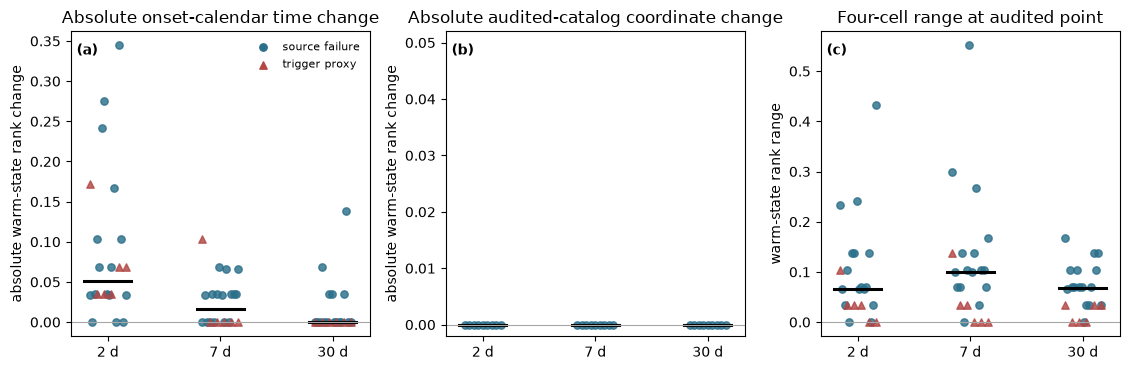

In [3]:
colors={'source_failure':'#2b6f8a','trigger_proxy':'#b24745'}; markers={'source_failure':'o','trigger_proxy':'^'}
panels=[(p,'absolute_time_warm_rank','Absolute onset-calendar time change'),(o,'absolute_coordinate_warm_rank','Absolute audited-catalog coordinate change'),(p,'onset_four_cell_warm_rank_range','Four-cell range at audited point')]
fig,axes=plt.subplots(1,3,figsize=(11.4,3.8))
for letter,ax,(source,column,title) in zip('abc',axes,panels):
    for k,window in enumerate(order):
        q=source[source.window==window]
        for role in colors:
            r=q[q.onset_role==role]
            x=k+np.linspace(-.16,.16,len(r))
            ax.scatter(x,r[column],s=28,color=colors[role],marker=markers[role],alpha=.82)
        ax.plot([k-.21,k+.21],[q[column].median()]*2,color='black',lw=2.2)
    ax.axhline(0,color='.65',lw=.8); ax.set(xticks=range(3),xticklabels=['2 d','7 d','30 d'],title=title)
    ax.text(.02,.96,f'({letter})',transform=ax.transAxes,ha='left',va='top',fontweight='bold')
axes[0].set_ylabel('absolute warm-state rank change'); axes[1].set(ylabel='absolute warm-state rank change',ylim=(-.002,.052)); axes[2].set_ylabel('warm-state rank range')
for role in colors: axes[0].scatter([],[],s=28,color=colors[role],marker=markers[role],label=role.replace('_',' '))
axes[0].legend(frameon=False,fontsize=8,loc='upper right'); fig.tight_layout()
fig.savefig(figures/'audited_reanalysis_sensitivity.pdf'); fig.savefig(figures/'audited_reanalysis_sensitivity.png',dpi=180)
plt.show()

## Bounded reading

For the seven-day window, the 22 onset-aligned warm-state ranks have median 0.741 (interquartile range 0.448--0.922); the 18 component representatives have median 0.650 (0.412--0.815). The signed onset-minus-calendar rank shift has median 0.000 (0.000--0.025), its absolute value has median 0.017 (0.000--0.034), and the signed mean-temperature shift has median 0.152 K (0.014--0.231 K). All nine old-pilot overlaps retain the same primary ERA5 cell, so their absolute primary-cell coordinate rank contrast is zero; their median absolute combined old-to-new warm-rank contrasts are 0.069, 0.034, and 0.000 at two, seven, and 30 days. This conditional result does not validate unresolved catalog coordinates. The median seven-day four-cell rank range is 0.100 and reaches 0.552, exceeding the median absolute timing contrast but measuring nominal grid assignment rather than positional uncertainty.

At model elevation, the median seven-day count is 93.5 of 168 2-m air-temperature hours above 273.15 K. A site 1 km above the model cell has a median of zero hours for each registered lapse rate, whereas a site 1 km below has medians of 161.5--168 hours. These are air-temperature scenarios, not reconstructed source elevations or material-thaw estimates. The selected failures have no non-failing risk set, so none of these ranks or contrasts estimates failure probability, climate triggering, or attribution.